# Prepare image and mask

In [9]:
import os

def prepare_data(input_dir, target_dir, img_size, num_classes, batch_size) :

    input_img_paths = sorted(
        [
            os.path.join(input_dir, fname)
            for fname in os.listdir(input_dir)
            if fname.endswith(".jpg")
        ]
    )
    target_img_paths = sorted(
        [
            os.path.join(target_dir, fname)
            for fname in os.listdir(target_dir)
            if fname.endswith(".png") and not fname.startswith(".")
        ]
    )

    print("Number of samples:", len(input_img_paths))

    for input_path, target_path in zip(input_img_paths[:10], target_img_paths[:10]):
        print(input_path, "|", target_path)

    return input_img_paths, target_img_paths

In [10]:
img_size = (640, 640)
num_classes = 2
batch_size = 32

In [11]:
train_input_img_paths, train_target_img_paths = prepare_data("train2/images/", "train2/masks/", img_size, num_classes, batch_size)
test_input_img_paths, test_target_img_paths = prepare_data("test2/images/", "test2/masks/", img_size, num_classes, batch_size)
valid_input_img_paths, valid_target_img_paths = prepare_data("valid2/images/", "valid2/masks/", img_size, num_classes, batch_size)


Number of samples: 1502
train2/images/1000_jpg.rf.1c16148495900a466a53f121ec6af0a9.jpg | train2/masks/1000_jpg.rf.1c16148495900a466a53f121ec6af0a9_seg_0.png
train2/images/1002_jpg.rf.57d3a8702704771f3315b19aac1aaae7.jpg | train2/masks/1002_jpg.rf.57d3a8702704771f3315b19aac1aaae7_seg_0.png
train2/images/1003_jpg.rf.9caed0c16ef6b6a9cc174256657810c1.jpg | train2/masks/1003_jpg.rf.9caed0c16ef6b6a9cc174256657810c1_seg_0.png
train2/images/1004_jpg.rf.373053c1dd48b8a6bc7ac7f93d4702ac.jpg | train2/masks/1004_jpg.rf.373053c1dd48b8a6bc7ac7f93d4702ac_seg_0.png
train2/images/1005_jpg.rf.26a35018e228afa0f075d4a09fd8769b.jpg | train2/masks/1005_jpg.rf.26a35018e228afa0f075d4a09fd8769b_seg_0.png
train2/images/1008_jpg.rf.492d7251d486bdcdc078e388dad8d205.jpg | train2/masks/1008_jpg.rf.492d7251d486bdcdc078e388dad8d205_seg_0.png
train2/images/100_jpg.rf.277787736bda26448d531e9285a5b086.jpg | train2/masks/100_jpg.rf.277787736bda26448d531e9285a5b086_seg_0.png
train2/images/1010_jpg.rf.82ea169b57b773929009f

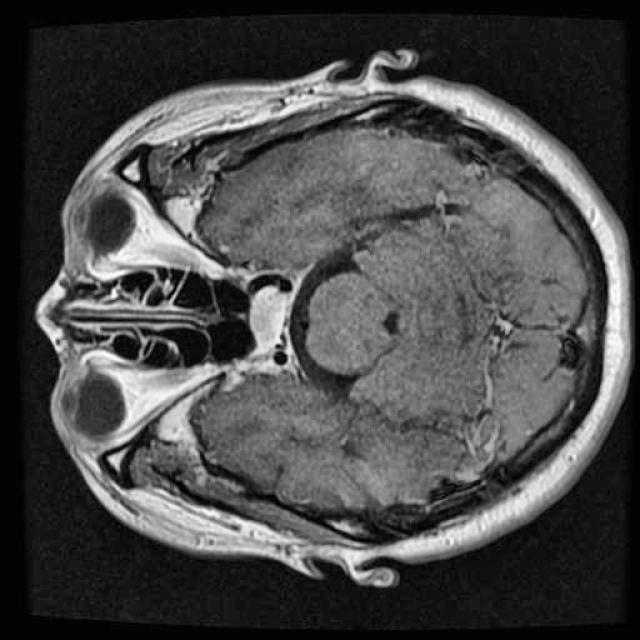

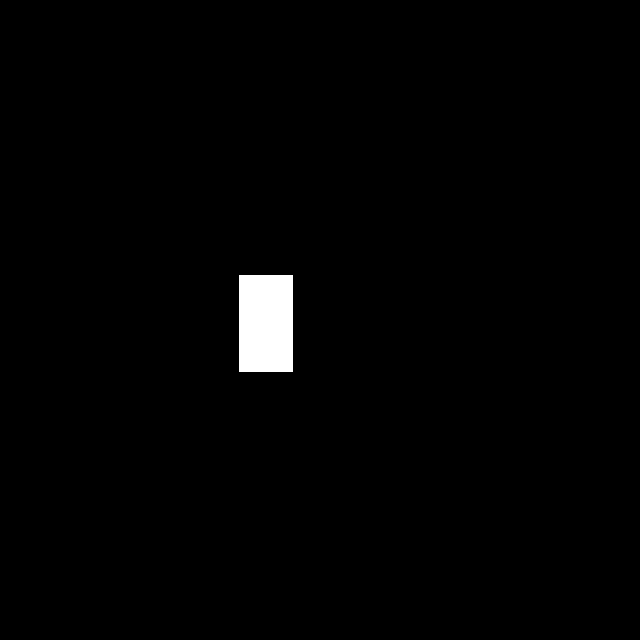

In [12]:
from IPython.display import Image, display
from keras.utils import load_img
from PIL import ImageOps

# Display input image #7
display(Image(filename=train_input_img_paths[9]))

# Display auto-contrast version of corresponding target (per-pixel categories)
img = ImageOps.autocontrast(load_img(train_target_img_paths[9]))
display(img)

# Prepare dataset to load & vectorize batches of data


In [13]:
import keras
import numpy as np
from tensorflow import data as tf_data
from tensorflow import image as tf_image
from tensorflow import io as tf_io


def get_dataset(
    batch_size,
    img_size,
    input_img_paths,
    target_img_paths,
    max_dataset_len=None,
):
    """Returns a TF Dataset."""

    def load_img_masks(input_img_path, target_img_path):
        input_img = tf_io.read_file(input_img_path)
        input_img = tf_io.decode_png(input_img, channels=3)
        input_img = tf_image.resize(input_img, img_size)
        input_img = tf_image.convert_image_dtype(input_img, "float32")

        target_img = tf_io.read_file(target_img_path)
        target_img = tf_io.decode_png(target_img, channels=1)
        target_img = tf_image.resize(target_img, img_size, method="nearest")
        target_img = tf_image.convert_image_dtype(target_img, "uint8")

        # Ground truth labels are 1, 2, 3. Subtract one to make them 0, 1, 2:
        target_img -= 1
        return input_img, target_img

    # For faster debugging, limit the size of data
    if max_dataset_len:
        input_img_paths = input_img_paths[:max_dataset_len]
        target_img_paths = target_img_paths[:max_dataset_len]
    dataset = tf_data.Dataset.from_tensor_slices((input_img_paths, target_img_paths))
    dataset = dataset.map(load_img_masks, num_parallel_calls=tf_data.AUTOTUNE)
    return dataset.batch(batch_size)

# Load Dataset

In [14]:
train_dataset = get_dataset(
    batch_size,
    img_size,
    train_input_img_paths,
    train_target_img_paths,
    max_dataset_len=1000,
)
valid_dataset = get_dataset(
    batch_size, img_size, valid_input_img_paths, valid_target_img_paths
)

# Prepare U-Net Exceptional Model

In [15]:
from keras import layers


def get_model(img_size, num_classes):
    inputs = keras.Input(shape=img_size + (3,))

    ### [First half of the network: downsampling inputs] ###

    # Entry block
    x = layers.Conv2D(32, 3, strides=2, padding="same")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    previous_block_activation = x  # Set aside residual

    # Blocks 1, 2, 3 are identical apart from the feature depth.
    for filters in [64, 128, 256]:
        x = layers.Activation("relu")(x)
        x = layers.SeparableConv2D(filters, 3, padding="same")(x)
        x = layers.BatchNormalization()(x)

        x = layers.Activation("relu")(x)
        x = layers.SeparableConv2D(filters, 3, padding="same")(x)
        x = layers.BatchNormalization()(x)

        x = layers.MaxPooling2D(3, strides=2, padding="same")(x)

        # Project residual
        residual = layers.Conv2D(filters, 1, strides=2, padding="same")(
            previous_block_activation
        )
        x = layers.add([x, residual])  # Add back residual
        previous_block_activation = x  # Set aside next residual

    ### [Second half of the network: upsampling inputs] ###

    for filters in [256, 128, 64, 32]:
        x = layers.Activation("relu")(x)
        x = layers.Conv2DTranspose(filters, 3, padding="same")(x)
        x = layers.BatchNormalization()(x)

        x = layers.Activation("relu")(x)
        x = layers.Conv2DTranspose(filters, 3, padding="same")(x)
        x = layers.BatchNormalization()(x)

        x = layers.UpSampling2D(2)(x)

        # Project residual
        residual = layers.UpSampling2D(2)(previous_block_activation)
        residual = layers.Conv2D(filters, 1, padding="same")(residual)
        x = layers.add([x, residual])  # Add back residual
        previous_block_activation = x  # Set aside next residual

    # Add a per-pixel classification layer
    outputs = layers.Conv2D(num_classes, 3, activation="softmax", padding="same")(x)

    # Define the model
    model = keras.Model(inputs, outputs)
    return model


# Build model
model = get_model(img_size, num_classes)
model.summary()

Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_2 (InputLayer)        [(None, 640, 640, 3)]        0         []                            
                                                                                                  
 conv2d_9 (Conv2D)           (None, 320, 320, 32)         896       ['input_2[0][0]']             
                                                                                                  
 batch_normalization_15 (Ba  (None, 320, 320, 32)         128       ['conv2d_9[0][0]']            
 tchNormalization)                                                                                
                                                                                                  
 activation_15 (Activation)  (None, 320, 320, 32)         0         ['batch_normalization_15

# Train Model

In [16]:
# Configure the model for training.
# We use the "sparse" version of categorical_crossentropy
# because our target data is integers.
model.compile(
    optimizer=keras.optimizers.Adam(1e-4), loss="sparse_categorical_crossentropy"
)

callbacks = [
    keras.callbacks.ModelCheckpoint("oxford_segmentation.keras", save_best_only=True)
]

# Train the model, doing validation at the end of each epoch.
epochs = 10
model.fit(
    train_dataset,
    epochs=epochs,
    validation_data=valid_dataset,
    callbacks=callbacks,
    verbose=2,
)

Epoch 1/10


InvalidArgumentError: Graph execution error:

Detected at node DecodePng_1 defined at (most recent call last):
<stack traces unavailable>
Detected at node DecodePng_1 defined at (most recent call last):
<stack traces unavailable>
2 root error(s) found.
  (0) INVALID_ARGUMENT:  Unknown image file format. One of JPEG, PNG, GIF, BMP required.
	 [[{{node DecodePng_1}}]]
	 [[IteratorGetNext]]
	 [[IteratorGetNext/_2]]
  (1) INVALID_ARGUMENT:  Unknown image file format. One of JPEG, PNG, GIF, BMP required.
	 [[{{node DecodePng_1}}]]
	 [[IteratorGetNext]]
0 successful operations.
0 derived errors ignored. [Op:__inference_train_function_18715]

In [19]:
import os
import cv2
import imghdr

def check_images( s_dir, ext_list):
    bad_images=[]
    bad_ext=[]
    s_list= os.listdir(s_dir)
    for klass in s_list:
        klass_path=os.path.join (s_dir, klass)
        print ('processing class directory ', klass)
        if os.path.isdir(klass_path):
            file_list=os.listdir(klass_path)
            for f in file_list:               
                f_path=os.path.join (klass_path,f)
                tip = imghdr.what(f_path)
                if ext_list.count(tip) == 0:
                  bad_images.append(f_path)
                if os.path.isfile(f_path):
                    try:
                        img=cv2.imread(f_path)
                        shape=img.shape
                    except:
                        print('file ', f_path, ' is not a valid image file')
                        bad_images.append(f_path)
                else:
                    print('*** fatal error, you a sub directory ', f, ' in class directory ', klass)
        else:
            print ('*** WARNING*** you have files in ', s_dir, ' it should only contain sub directories')
    return bad_images, bad_ext

source_dir =r'train2/'
good_exts=['jpg', 'png', 'jpeg', 'gif', 'bmp' ] # list of acceptable extensions
bad_file_list, bad_ext_list=check_images(source_dir, good_exts)
if len(bad_file_list) !=0:
    print('improper image files are listed below')
    for i in range (len(bad_file_list)):
        print (bad_file_list[i])
else:
    print(' no improper image files were found')

processing class directory  images
processing class directory  masks
improper image files are listed below
train2/masks/1000_jpg.rf.1c16148495900a466a53f121ec6af0a9_seg_0.png
train2/masks/1002_jpg.rf.57d3a8702704771f3315b19aac1aaae7_seg_0.png
train2/masks/1003_jpg.rf.9caed0c16ef6b6a9cc174256657810c1_seg_0.png
train2/masks/1004_jpg.rf.373053c1dd48b8a6bc7ac7f93d4702ac_seg_0.png
train2/masks/1005_jpg.rf.26a35018e228afa0f075d4a09fd8769b_seg_0.png
train2/masks/1008_jpg.rf.492d7251d486bdcdc078e388dad8d205_seg_0.png
train2/masks/100_jpg.rf.277787736bda26448d531e9285a5b086_seg_0.png
train2/masks/1010_jpg.rf.82ea169b57b773929009fa13b7aa704b_seg_0.png
train2/masks/1012_jpg.rf.453866333dd04def7d83896e33f77155_seg_0.png
train2/masks/1013_jpg.rf.05704b16d3d0f4dd9803edc53b723520_seg_0.png
train2/masks/1014_jpg.rf.e4d01976894e0d082ed45905b50c1243_seg_0.png
train2/masks/1015_jpg.rf.4f61b1e8e47b49b874b6280e7a630aa4_seg_0.png
train2/masks/1016_jpg.rf.1e728d7539e99ed821f48d5047e6307f_seg_0.png
train2/mas